<a href="https://colab.research.google.com/github/purvatawade/Smart-Inventory-Sales-Optimizer/blob/main/retail_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
df = pd.read_csv('superstore.csv', encoding='utf-8')
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_').str.lower()
print(f"Workspace Ready! Total loaded records: {len(df)} rows.")

Workspace Ready! Total loaded records: 10800 rows.


In [11]:
category_counts = df.groupby('sub_category').size().sort_values(ascending=False)
print("--- TOP 5 HIGH-VOLUME SUB-CATEGORIES ---")
print(category_counts.head(5))

--- TOP 5 HIGH-VOLUME SUB-CATEGORIES ---
sub_category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
dtype: int64


In [13]:
binders_df = df[df['sub_category'] == 'Binders'].copy()
timeline_df = binders_df.groupby('order_date')['quantity'].sum().reset_index()
timeline_df.columns=['ds', 'y']
timeline_df['ds'] = pd.to_datetime(timeline_df['ds'])
print("--- PROPHET-READY DATA FORMAT ---")
print(timeline_df.head())
print(f"\nSuccess! Total data points found for training: {len(timeline_df)} dates.")

--- PROPHET-READY DATA FORMAT ---
          ds     y
0 2018-01-01  21.0
1 2018-01-12   5.0
2 2015-01-13   5.0
3 2016-01-13   3.0
4 2018-01-14   7.0

Success! Total data points found for training: 776 dates.


In [14]:
from prophet import Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(timeline_df)
future_dates = model.make_future_dataframe(periods=90, freq='D')
forecast = model.predict(future_dates)
print("--- METAPROPHET INVENTORY DEMAND FORECAST MATRIX ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

--- METAPROPHET INVENTORY DEMAND FORECAST MATRIX ---
            ds      yhat  yhat_lower  yhat_upper
861 2019-03-26  9.089415    1.807972   16.101512
862 2019-03-27  8.319857    1.036221   15.959603
863 2019-03-28  7.246747   -0.193418   15.016049
864 2019-03-29  8.867593    1.078007   15.961707
865 2019-03-30  9.624182    1.605484   16.745907


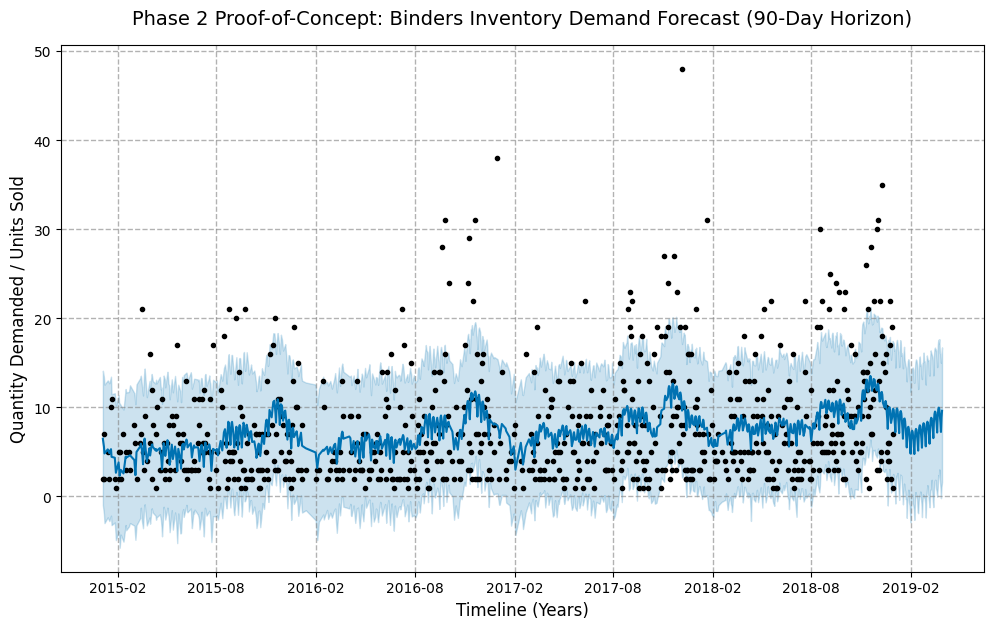

In [15]:
import matplotlib.pyplot as plt
fig1 = model.plot(forecast)
plt.title("Phase 2 Proof-of-Concept: Binders Inventory Demand Forecast (90-Day Horizon)", fontsize=14, pad=15)
plt.xlabel("Timeline (Years)", fontsize=12)
plt.ylabel("Quantity Demanded / Units Sold", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()